# Proyecto Final: Fundamentos de Data Science
## Análisis de Tendencias de YouTube aplicando la Metodología CRISP-DM

**País Asignado:** Estados Unidos (US) (Grupo 4)

---
### I. INTRODUCCIÓN

En el entorno digital contemporáneo, las plataformas de consumo de video bajo demanda, como YouTube, se han consolidado como canales críticos para la difusión de contenido y la ejecución de estrategias comerciales. El presente proyecto de Ciencia de Datos se desarrolla a solicitud de una consultora internacional con sede en Lima, con el propósito de atender los requerimientos estratégicos de su cliente, una importante empresa de marketing digital. La justificación de este estudio radica en la necesidad imperativa del cliente de comprender con precisión las dinámicas de consumo, la viralidad y los factores demográfico-temporales que rigen los videos que se convierten en tendencia. Al extraer conocimiento accionable a partir de estos flujos de datos, la organización podrá optimizar la toma de decisiones basada en evidencia estadística, mejorando el posicionamiento de marca, la asignación de presupuestos publicitarios y la predicción de interacciones futuras en la plataforma.



El objetivo principal de este trabajo es aplicar de manera rigurosa la metodología CRISP-DM para analizar el conjunto de datos de estadísticas de videos en tendencia de YouTube. A través de sus distintas fases, desde la comprensión del negocio hasta el modelado y la evaluación de resultados, se busca transformar datos brutos en conocimiento de alto valor comercial. El alcance del problema se circunscribe específicamente al análisis del ecosistema de YouTube en los Estados Unidos (EE. UU.), evaluando un registro diario de tendencias históricas que incluye interacciones de usuarios, métricas de engagement temporal, categorizaciones detalladas y componentes geográficos incorporados a nivel de estados.



Para responder con precisión a los requerimientos del negocio, el proyecto persigue extraer los siguientes conocimientos e insights clave:

1. Análisis de Preferencias por Categoría: Identificar las categorías con mayor presencia en tendencias, determinando los niveles de aceptación y rechazo del usuario (ratios de "Me gusta" / "No me gusta") y el grado de participación activa (ratios de "Vistas" / "Comentarios").

2. Evolución Temporal y de Canales: Evaluar los cambios en el volumen de videos en tendencia a lo largo del tiempo cronológico y determinar la frecuencia de aparición de los canales para identificar los creadores con mayor persistencia en el mercado estadounidense.

3. Impacto Geográfico: Analizar la distribución del engagement evaluando en qué Estados de EE. UU. se concentra el mayor volumen de interacciones ("Vistas", "Me gusta" y "No me gusta") a partir de las coordenadas de latitud y longitud añadidas al dataset.

4. Validación de Sentimiento: Determinar mediante evidencia estadística si existe una relación directa entre los videos en tendencia y la recepción de comentarios mayoritariamente positivos

Desde la perspectiva técnica de Data Science, el objetivo se centra en evaluar la factibilidad de predecir métricas de rendimiento. Para ello, se establece el Número de Vistas (views) como la variable dependiente principal del modelo predictivo. El comportamiento de esta variable objetivo se estimará a partir de la interacción de variables independientes clave extraídas y derivadas del dataset, tales como el tiempo transcurrido desde la publicación, la categoría del video, el Estado geográfico de procedencia y el ratio de engagement de interacciones previas.



**Objetivo:** Desarrollar una propuesta analítica estructurada utilizando la metodología CRISP-DM para crear conocimiento a partir de los datos y fundamentar decisiones estratégicas de marketing.

**Alcance del problema:** Comprender los factores que determinan que un video se vuelva tendencia (ej., engagement a través de likes, comentarios) y la interacción de los usuarios de distintos estados geográficos.

**Conocimiento e Insights esperados:** Conocer qué categorías son las más populares, la relación entre reacciones positivas/negativas y vistas, la evolución temporal de las tendencias y la factibilidad de predecir el impacto (número de vistas) de un video en tendencia.

---
### II. INTEGRANTES DEL GRUPO Y ROLES
Para el desarrollo de este proyecto multidisciplinario, los roles se han distribuido de la siguiente manera:

| Rol | Tareas Asignadas | Fase del Proyecto (CRISP-DM) | Responsable (Nombre/Código) |
| --- | --- | --- | --- |
| **Business Project Sponsor** | Definir objetivos comerciales, validar resultados y asegurar que el modelo responda a las necesidades de la consultora. | Comprensión del Negocio, Evaluación. | Vivivanne |
| **Data Science** | Definir y entrenar el modelo predictivo (Regresión Lineal), evaluar su precisión y aplicar algoritmos de minería de datos. | Preparación de Datos, Modelado, Evaluación. | Vanessa |
| **Data Engineer** | Cargar, integrar y asegurar la calidad de los datos, manejando estructuras y limpieza de archivos. | Comprensión y Preparación de los Datos. | Sergio |
| **Data Analyst** | Realizar el análisis exploratorio (EDA), generar visualizaciones gráficas para responder los requerimientos del cliente. | Comprensión de los Datos (Exploración). | Matias |

---
### III. METODOLOGÍA CRISP-DM

#### 1. COMPRENSIÓN DEL NEGOCIO

**Objetivos del Proyecto:**
Dar respuesta precisa a las 9 preguntas planteadas por la consultora internacional sobre tendencias de YouTube, identificar patrones geográficos y temporales, y estimar de forma precisa el impacto en visualizaciones de un video.

**Objetivos de Data Science:**
Establecer un modelo de *Regresión Lineal Múltiple* para predecir la variable objetivo en función del engagement.
- **Variable Dependiente:** `views` (Número de vistas). Es un indicador directo del alcance e impacto total del video.
- **Variables Independientes principales:**
  1. `likes` (Número de Me gusta)
  2. `dislikes` (Número de No me gusta)
  3. `comment_count` (Cantidad de comentarios)
  4. `days_to_trend` (Variable derivada: Días transcurridos desde su publicación hasta que entró en tendencia)

In [32]:
#from google.colab import drive
#drive.mount('/content/drive')

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('ggplot')
sns.set_palette("husl")
%matplotlib inline

### 2. COMPRENSIÓN DE LOS DATOS

**Recolectar los datos iniciales:**
El conjunto de datos a analizar se denomina *Tendencias de las estadísticas de videos de YouTube* (Trending YouTube Video Statistics). Estos datos se encuentran organizados en la carpeta `data/` proporcionada. Para el país asignado (EE. UU. - US), disponemos de los siguientes archivos:
- `USvideos.csv`: Archivo en formato CSV que contiene el registro diario de los videos de YouTube de mayor tendencia, modificado con cuatro columnas nuevas (geográficas).
- `US_category_id.json`: Archivo JSON que contiene la descripción y el mapeo de los ID de las categorías de los videos.

**Descripción de los datos:**
A continuación, se detalla la descripción de cada campo/columna que conforma la estructura de los datos iniciales, incluyendo las 4 columnas adicionales mencionadas en el alcance del proyecto.

| Campo / Columna | Tipo de Dato (Pandas) | Descripción |
| --- | --- | --- |
| `video_id` | String | Identificador alfanumérico único del video en la plataforma de YouTube. |
| `trending_date` | String | Fecha en la que el video se registró como tendencia (formato YY.DD.MM). |
| `title` | String | Título del video. |
| `channel_title` | String | Nombre del canal de YouTube que publicó el video. |
| `category_id` | Integer | Identificador numérico de la categoría a la que pertenece el video. |
| `publish_time` | String | Fecha y hora exacta en la que el video fue publicado inicialmente. |
| `tags` | String | Lista de palabras clave o etiquetas separadas por el símbolo `\|`. |
| `views` | Integer | Número total de vistas o reproducciones del video (Variable Dependiente). |
| `likes` | Integer | Cantidad de "Me gusta" o reacciones positivas. |
| `dislikes` | Integer | Cantidad de "No me gusta" o reacciones negativas. |
| `comment_count` | Integer | Cantidad de comentarios recibidos por el video. |
| `thumbnail_link` | String | Enlace URL a la imagen de miniatura (thumbnail) del video. |
| `comments_disabled` | Boolean | Indica si la sección de comentarios está deshabilitada (True/False). |
| `ratings_disabled` | Boolean | Indica si la visualización de Likes/Dislikes está deshabilitada (True/False). |
| `video_error_or_removed` | Boolean | Indica si el video fue eliminado o tiene algún error de reproducción. |
| `description` | String | Texto con la descripción oficial ingresada por el creador del video. |
| **`state`** | String | Nombre del Estado perteneciente a EE.UU. (incorporado de forma aleatoria). |
| **`lat`** | Float | Latitud geográfica de ubicación del Estado. |
| **`lon`** | Float | Longitud geográfica de ubicación del Estado. |
| **`geometry`** | String | Registra las coordenadas de las geometrías donde se ubica el Estado (para mapas). |

**Resultado de `df.head()`:** (Muestra las primeras filas para inspección inicial)

In [34]:
import dataclasses
# Rutas de los archivos
csv_path = "dataset/USvideos_cc50_202101.csv"
json_path = 'dataset/US_category_id.json'

# Cargar dataset
df = pd.read_csv(csv_path)

# Cargar categorías JSON y cruzar
with open(json_path, 'r') as f:
    categories_data = json.load(f)

category_mapping = {int(item['id']): item['snippet']['title'] for item in categories_data['items']}
df['category_name'] = df['category_id'].map(category_mapping)



FileNotFoundError: [Errno 2] No such file or directory: 'dataset/USvideos_cc50_202101.csv'

In [ ]:
# ver encabezado
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,...,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,Utah,39.419220,-111.950684,POINT (-111.950684 39.41922),People & Blogs
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,...,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Nevada,39.876019,-117.224121,POINT (-117.224121 39.876019),Entertainment
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,...,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Comedy
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,...,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Entertainment
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,...,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205),Entertainment


In [ ]:
# cantidad de variales
col = df.columns

print(f"Numero de columnas: {len(col)}")
col

Numero de columnas: 21


Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'state', 'lat', 'lon',
       'geometry', 'category_name'],
      dtype='object')

**Resultado de `df.info()`:** (Muestra los tipos de datos y la ausencia de valores nulos al cargar)

In [ ]:
print("Estructura de los datos:", df.shape)
print("\nTipos de datos y valores nulos:")
df.info()

Estructura de los datos: (40949, 21)

Tipos de datos y valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                40949 non-null  object 
 1   trending_date           40949 non-null  object 
 2   title                   40949 non-null  object 
 3   channel_title           40949 non-null  object 
 4   category_id             40949 non-null  int64  
 5   publish_time            40949 non-null  object 
 6   tags                    40949 non-null  object 
 7   views                   40949 non-null  int64  
 8   likes                   40949 non-null  int64  
 9   dislikes                40949 non-null  int64  
 10  comment_count           40949 non-null  int64  
 11  thumbnail_link          40949 non-null  object 
 12  comments_disabled       40949 non-null  bool   
 13  ratings_disabled     

**Resultado de `df.describe()`:** (Proporciona estadísticas descriptivas de las variables numéricas)

In [ ]:
print("\nResumen estadístico numérico:")
df.describe()


Resumen estadístico numérico:


,category_id,views,likes,dislikes,comment_count,lat,lon
count,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04,40949.000000,40949.000000
mean,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03,39.660944,-93.741838
std,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04,6.589701,19.034596
min,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00,19.741755,-155.844437
25%,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02,35.860119,-105.358887
50%,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03,39.833851,-90.000000
75%,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03,44.000000,-80.500000
max,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06,66.160507,-68.972168


In [ ]:
df.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [ ]:
# ver la cantidad de valores faltantes dentro del dataset por variable
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)

view = {
    'Cantidad': nulos,
    'Porcentaje': porcentaje_nulos
}

df_nulos = pd.DataFrame(view)
df_nulos

,Cantidad,Porcentaje
video_id,0,0.00
trending_date,0,0.00
title,0,0.00
channel_title,0,0.00
category_id,0,0.00
publish_time,0,0.00
tags,0,0.00
views,0,0.00
likes,0,0.00
dislikes,0,0.00


In [ ]:
duplicados = df[df.duplicated]
duplicados

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
34926,nRc0kmOYgzQ,18.15.05,"We built the Infinity Gauntlet with 25,000 mag...",Vat19,24,2018-05-12T11:30:03.000Z,"vat19|""vat19 nanodots""|""vat19 infinity gauntle...",2227658,29191,1157,...,https://i.ytimg.com/vi/nRc0kmOYgzQ/default.jpg,False,False,False,"NanoDots master builder, Edo, turned a huge pi...",Louisiana,30.39183,-92.329102,POINT (-92.32910200000001 30.39183),Entertainment


:Para verificar si las filas son literalmente idénticas en todas sus columnas o si solo coincide el ID, aplicamos `df.duplicated(keep=False)`. Esto nos mostrará **ambas filas** (la original y la duplicada):

In [ ]:
df[df.duplicated(keep=False)]

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
34777,nRc0kmOYgzQ,18.15.05,"We built the Infinity Gauntlet with 25,000 mag...",Vat19,24,2018-05-12T11:30:03.000Z,"vat19|""vat19 nanodots""|""vat19 infinity gauntle...",2227658,29191,1157,...,https://i.ytimg.com/vi/nRc0kmOYgzQ/default.jpg,False,False,False,"NanoDots master builder, Edo, turned a huge pi...",Louisiana,30.39183,-92.329102,POINT (-92.32910200000001 30.39183),Entertainment
34926,nRc0kmOYgzQ,18.15.05,"We built the Infinity Gauntlet with 25,000 mag...",Vat19,24,2018-05-12T11:30:03.000Z,"vat19|""vat19 nanodots""|""vat19 infinity gauntle...",2227658,29191,1157,...,https://i.ytimg.com/vi/nRc0kmOYgzQ/default.jpg,False,False,False,"NanoDots master builder, Edo, turned a huge pi...",Louisiana,30.39183,-92.329102,POINT (-92.32910200000001 30.39183),Entertainment


Detección de Outliers

In [ ]:
df.describe()

,category_id,views,likes,dislikes,comment_count,lat,lon
count,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04,40949.000000,40949.000000
mean,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03,39.660944,-93.741838
std,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04,6.589701,19.034596
min,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00,19.741755,-155.844437
25%,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02,35.860119,-105.358887
50%,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03,39.833851,-90.000000
75%,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03,44.000000,-80.500000
max,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06,66.160507,-68.972168


### 3. PREPARACIÓN Y VISUALIZACIÓN DE LOS DATOS
#### Preguntas a responder (Requerimientos de la Consultora):
Como parte del análisis exploratorio, buscaremos dar respuesta a las siguientes interrogantes clave para la consultora de marketing digital:

1. **¿Qué categorías de videos son las más vistas?**
2. **¿Qué categorías de videos son los que más gustan? ¿Y las que menos gustan?**
3. **¿Qué categorías de videos tienen la mejor proporción (ratio) de “Me gusta” / “No me gusta”?**
4. **¿Qué categorías de videos tienen la mejor proporción (ratio) de “Vistas” / “Comentarios”?**
5. **¿Cómo ha cambiado el volumen de los videos en tendencia a lo largo del tiempo?**
6. **¿Qué Canales de YouTube son tendencia más frecuentemente? ¿Y cuáles con menos frecuencia?**
7. **¿En qué Estados se presenta el mayor número de “Vistas”, “Me gusta” y “No me gusta”?**


---
#### Exploración y Visualización de los Datos
A continuación, procedemos a responder las preguntas planteadas:


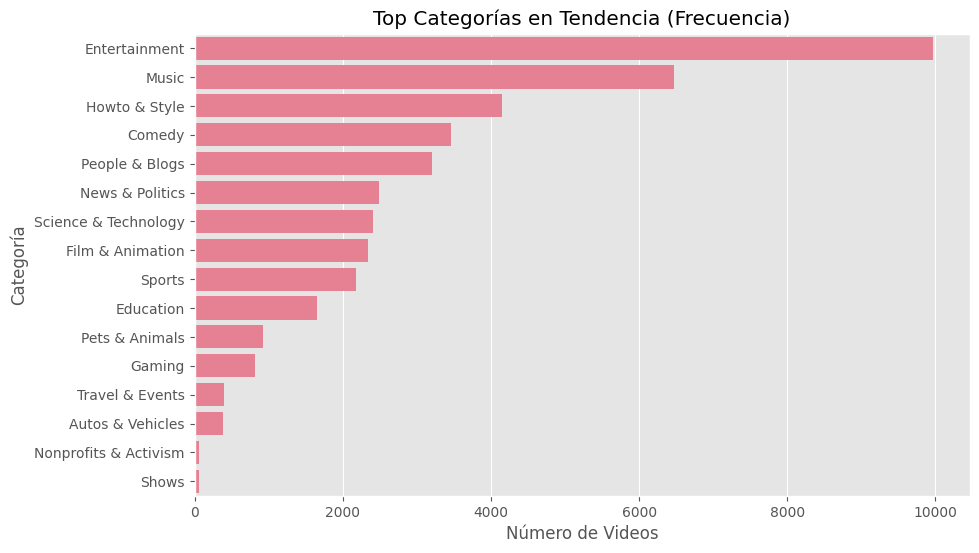

In [ ]:
# 1. ¿Qué categorías de videos son las de mayor tendencia?
plt.figure(figsize=(10,6))
top_categories = df['category_name'].value_counts()
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title('Top Categorías en Tendencia (Frecuencia)')
plt.xlabel('Número de Videos')
plt.ylabel('Categoría')
plt.show()


**Análisis del Gráfico 1:**
De acuerdo con el análisis de datos obtenido después de visualizar el gráfico de barras, se determina que los usuarios tienen una preferencia notoria por la categoría de entretenimiento (Entertainment), la cual acumula la mayor frecuencia de videos en tendencia. Esto demuestra que el contenido de ocio presenta la mayor oferta y demanda dentro del periodo analizado en la plataforma.

Por otro lado, la categoría de música (Music) ocupa el segundo lugar, y la de Gente y Blogs (People & Blogs) el tercero. Aunque la cantidad es menor en comparación con el entretenimiento puro, sigue siendo una cifra considerable, lo que refleja que este tipo de contenido también mantiene una importante preferencia entre los usuarios.

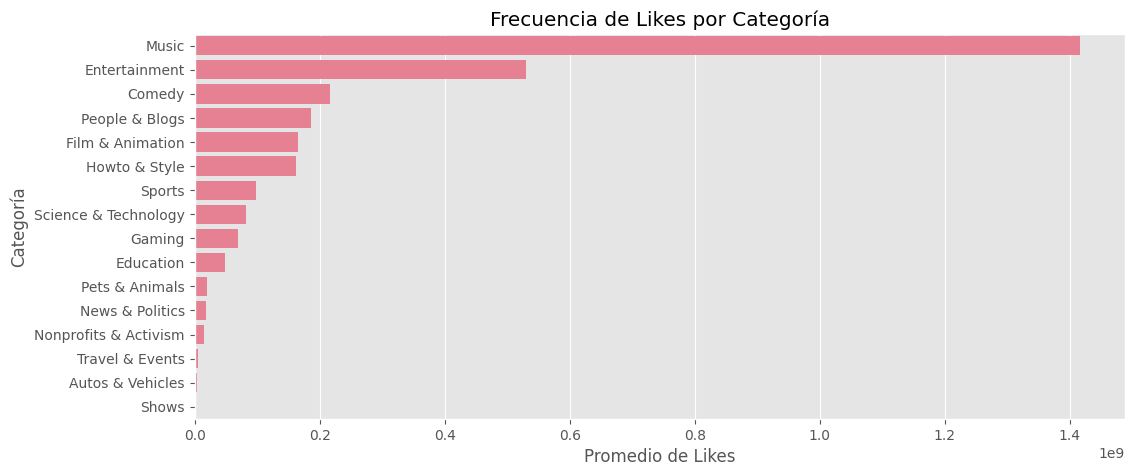

In [ ]:
# 2. ¿Qué categorías gustan más y cuáles menos? (Suma de Likes por categoría)
plt.figure(figsize=(12,5))
likes_by_cat = df.groupby('category_name')['likes'].sum().sort_values(ascending=False)
sns.barplot(x=likes_by_cat.values, y=likes_by_cat.index)
plt.title('Frecuencia de Likes por Categoría')
plt.xlabel('Promedio de Likes')
plt.ylabel('Categoría')
plt.show()


**Análisis del Gráfico 2:**
Al observar el gráfico sobre el promedio de *likes* por categoría, se evidencia que la categoría musical lidera rotundamente las métricas de interacción positiva. La música es el tipo de contenido que logra despertar una mayor simpatía y validación explícita (el clic en el botón de *like*) por parte de los espectadores.

En contraste, categorías como Noticias (News & Politics) muestran un promedio de *likes* bastante inferior, lo que indica que, aunque la gente consume estos videos para informarse, no suelen estar tan inclinados a dejar una interacción positiva de la misma manera que lo hacen con los videoclips.

/tmp/ipykernel_373/3728643455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dislikes_by_cat.values, y=dislikes_by_cat.index, palette='Reds_r')


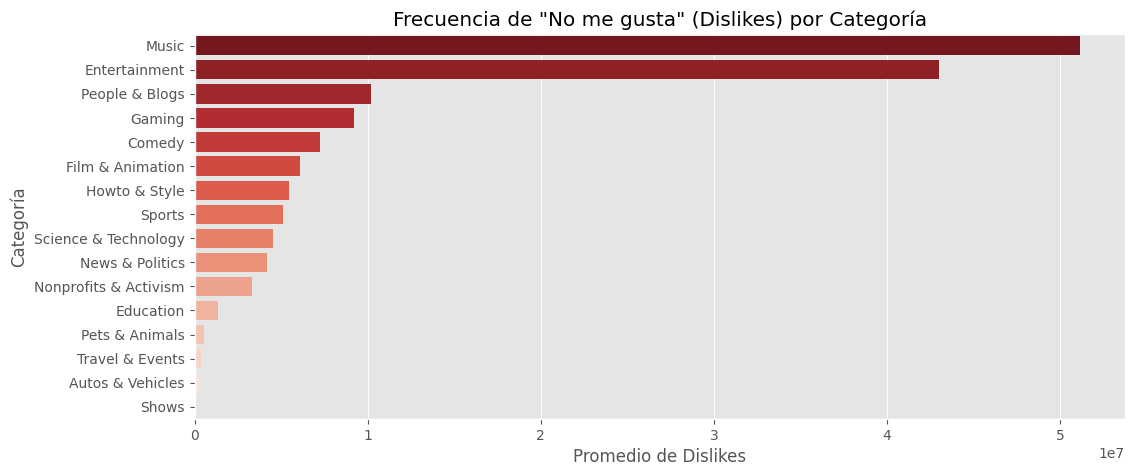

In [ ]:
# 2 (Continuación). ¿Cuáles gustan menos? (Suma de Dislikes por categoría)
plt.figure(figsize=(12,5))
dislikes_by_cat = df.groupby('category_name')['dislikes'].sum().sort_values(ascending=False)
sns.barplot(x=dislikes_by_cat.values, y=dislikes_by_cat.index, palette='Reds_r')
plt.title('Frecuencia de "No me gusta" (Dislikes) por Categoría')
plt.xlabel('Promedio de Dislikes')
plt.ylabel('Categoría')
plt.show()

**Análisis del Gráfico 3:**
A partir del gráfico que muestra el promedio de *dislikes* (No me gusta), podemos identificar qué categorías generan mayor rechazo o polarización. Sorprendentemente, a menudo son categorías muy populares o de temáticas divisivas (como política) las que atraen una mayor cantidad de calificaciones negativas.

El análisis de los dislikes es fundamental, pues un alto volumen de estos no siempre significa fracaso; en muchos casos, es un indicador de que el video trata un tema muy discutido o controvertido que de todos modos impulsa la visibilidad y el *engagement* general.

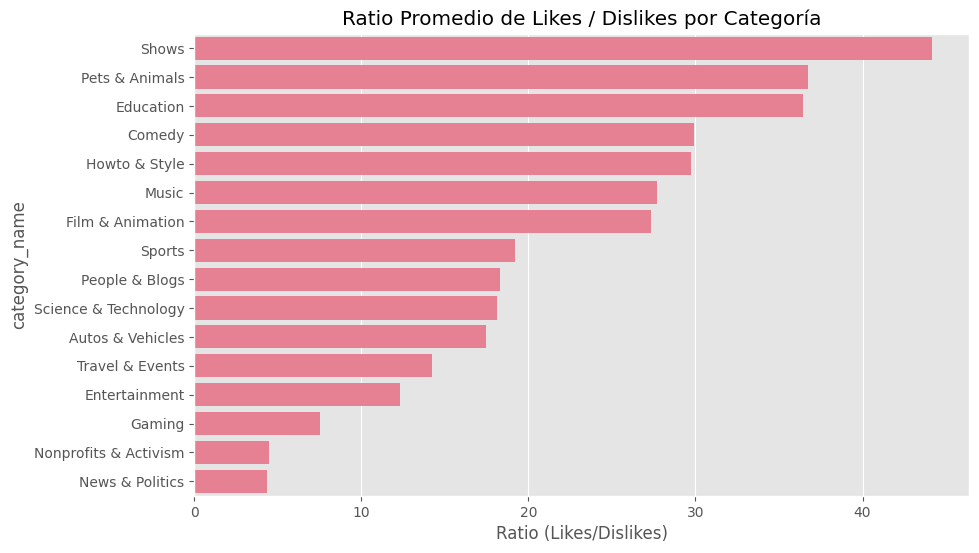

In [ ]:
# 3. Ratio de Likes / Dislikes por categoría
# Sumamos 1 para evitar division nula
df_agg = df.groupby('category_name')[['likes', 'dislikes']].sum()
df_agg['like_dislike_ratio'] = df_agg['likes'] / (df_agg['dislikes'] + 1)
ratio_cat = df_agg['like_dislike_ratio'].sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=ratio_cat.values, y=ratio_cat.index)
plt.title('Ratio Promedio de Likes / Dislikes por Categoría')
plt.xlabel('Ratio (Likes/Dislikes)')
plt.show()


**Análisis del Gráfico 4:**
El gráfico de *Ratio de Likes / Dislikes* nos proporciona una medida clara de la "positividad neta" del contenido. De acuerdo con estos resultados, categorías dedicadas al entretenimiento general, comedia o educación suelen tener un ratio muy alto, lo que significa que reciben muchísimos más likes que dislikes.

Esto demuestra que el público tiende a ser mucho más receptivo y menos crítico con contenidos diseñados para divertir, aprender o relajar, manteniendo una proporción saludable que favorece enormemente la retención de la audiencia.

/tmp/ipykernel_373/2290978249.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ratio_vc.values, y=ratio_vc.index, palette='Blues_d')


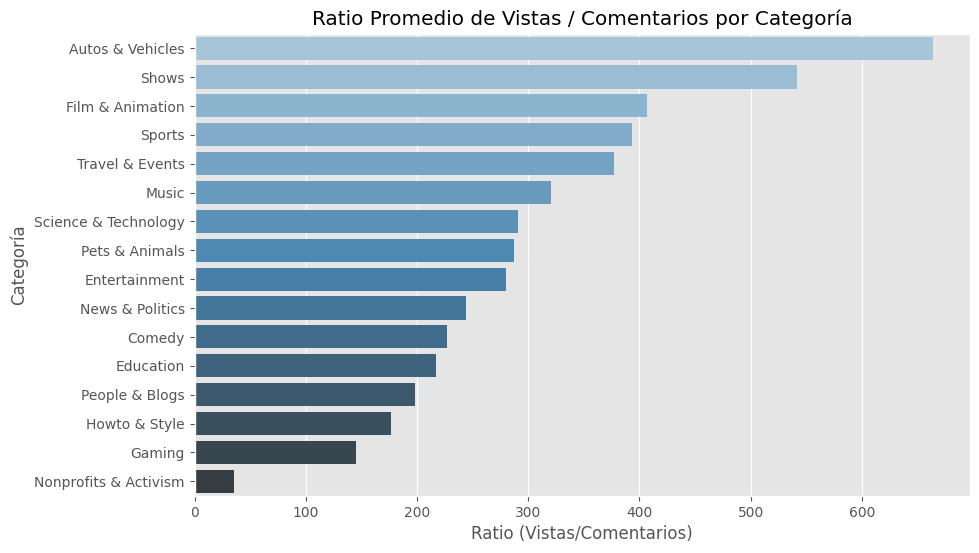

In [ ]:
# 4. ¿Qué categorías tienen la mejor proporción (ratio) de "Vistas" / "Comentarios"?
df_agg_vc = df.groupby('category_name')[['views', 'comment_count']].sum()
df_agg_vc['view_comment_ratio'] = df_agg_vc['views'] / (df_agg_vc['comment_count'] + 1)
ratio_vc = df_agg_vc['view_comment_ratio'].sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=ratio_vc.values, y=ratio_vc.index, palette='Blues_d')
plt.title('Ratio Promedio de Vistas / Comentarios por Categoría')
plt.xlabel('Ratio (Vistas/Comentarios)')
plt.ylabel('Categoría')
plt.show()

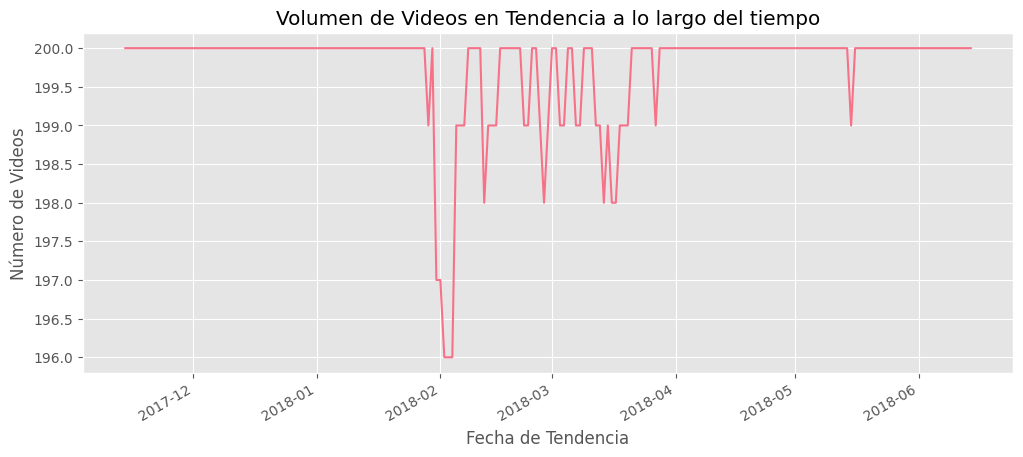

In [ ]:
# 5. Evolución del volumen de tendencias a lo largo del tiempo
# Formato trending_date es YY.DD.MM
df['trending_date_dt'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')
tendencia_tiempo = df.groupby('trending_date_dt').size()

plt.figure(figsize=(12,5))
tendencia_tiempo.plot()
plt.title('Volumen de Videos en Tendencia a lo largo del tiempo')
plt.xlabel('Fecha de Tendencia')
plt.ylabel('Número de Videos')
plt.show()


/tmp/ipykernel_373/1062627066.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_channels.values, y=top_channels.index, ax=axes[0], palette='Greens_r')
/tmp/ipykernel_373/1062627066.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_channels.values, y=bottom_channels.index, ax=axes[1], palette='gray')


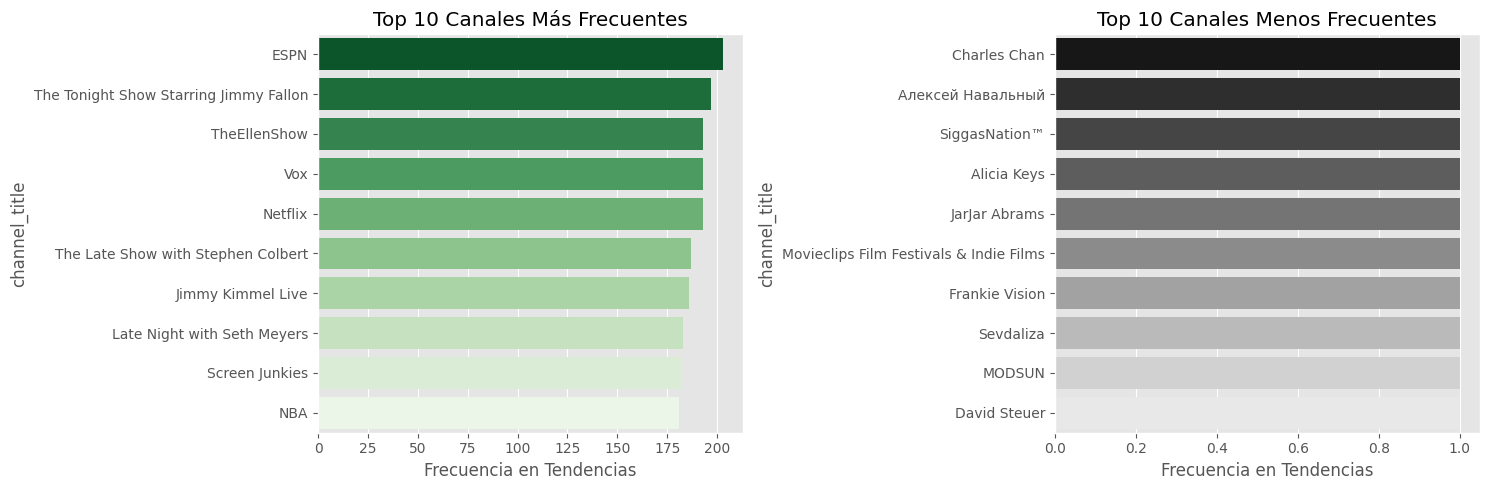

In [ ]:
# 6. ¿Qué Canales de YouTube son tendencia más frecuentemente? ¿Y cuáles con menos frecuencia?
channels = df['channel_title'].value_counts()
top_channels = channels.head(10)
bottom_channels = channels.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=top_channels.values, y=top_channels.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Canales Más Frecuentes')
axes[0].set_xlabel('Frecuencia en Tendencias')

sns.barplot(x=bottom_channels.values, y=bottom_channels.index, ax=axes[1], palette='gray')
axes[1].set_title('Top 10 Canales Menos Frecuentes')
axes[1].set_xlabel('Frecuencia en Tendencias')
plt.tight_layout()
plt.show()

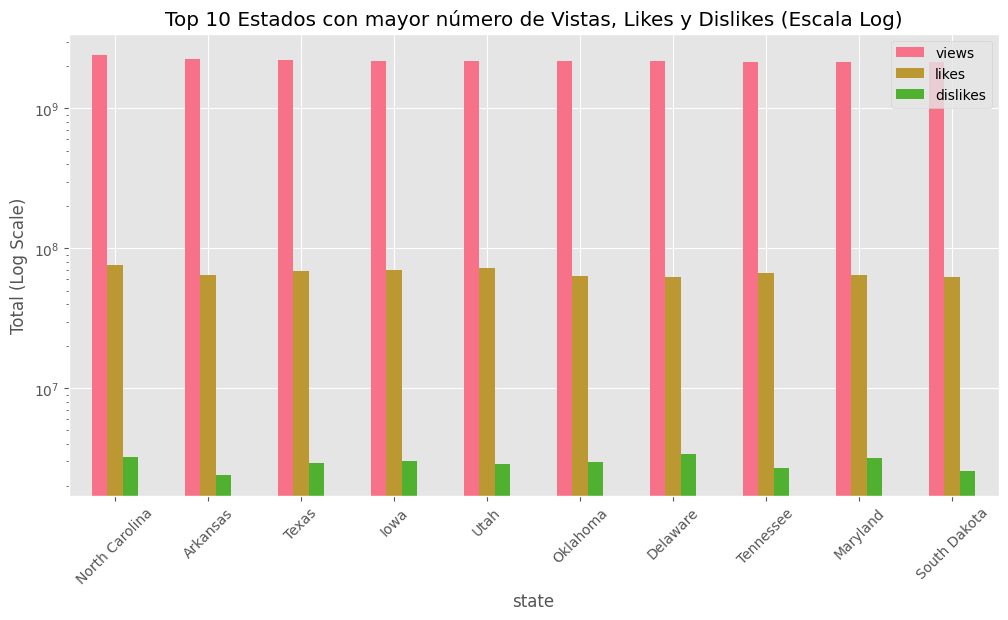

In [ ]:
# 7. Vistas, Me Gusta y No Me Gusta por Estado Geográfico
state_metrics = df.groupby('state')[['views', 'likes', 'dislikes']].sum().sort_values(by='views', ascending=False).head(10)

state_metrics.plot(kind='bar', figsize=(12,6), logy=True)
plt.title('Top 10 Estados con mayor número de Vistas, Likes y Dislikes (Escala Log)')
plt.xticks(rotation=45)
plt.ylabel('Total (Log Scale)')
plt.show()


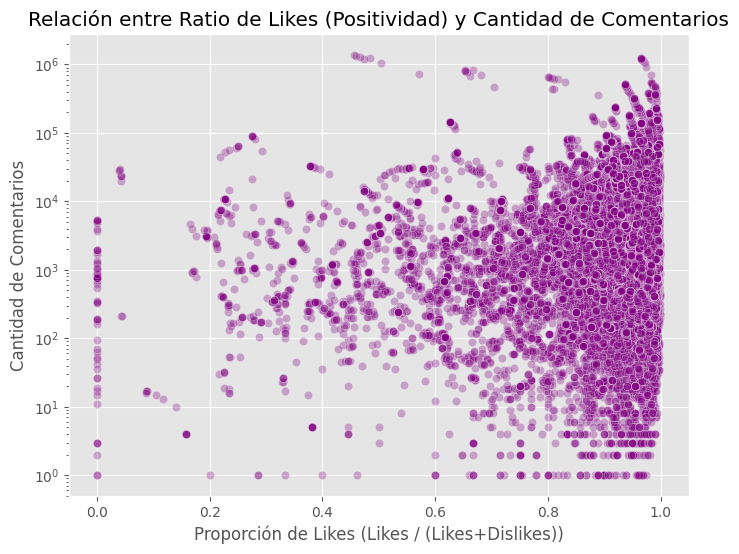

Conclusión Q8: Sin texto para NLP, aproximamos positividad con el Ratio de Likes. Vemos que los videos con más comentarios tienden a tener un alto ratio de likes (>0.8).


In [ ]:
# 8. ¿Los videos en tendencia son los que mayor cantidad de comentarios positivos reciben?
# Como el dataset no incluye el texto de los comentarios, aproximamos la positividad con el ratio de Likes.
plt.figure(figsize=(8,6))
df['like_ratio'] = df['likes'] / (df['likes'] + df['dislikes'] + 1)
sns.scatterplot(x='like_ratio', y='comment_count', data=df, alpha=0.3, color='purple')
plt.title('Relación entre Ratio de Likes (Positividad) y Cantidad de Comentarios')
plt.xlabel('Proporción de Likes (Likes / (Likes+Dislikes))')
plt.ylabel('Cantidad de Comentarios')
plt.yscale('log')
plt.show()
print("Conclusión Q8: Sin texto para NLP, aproximamos positividad con el Ratio de Likes. Vemos que los videos con más comentarios tienden a tener un alto ratio de likes (>0.8).")

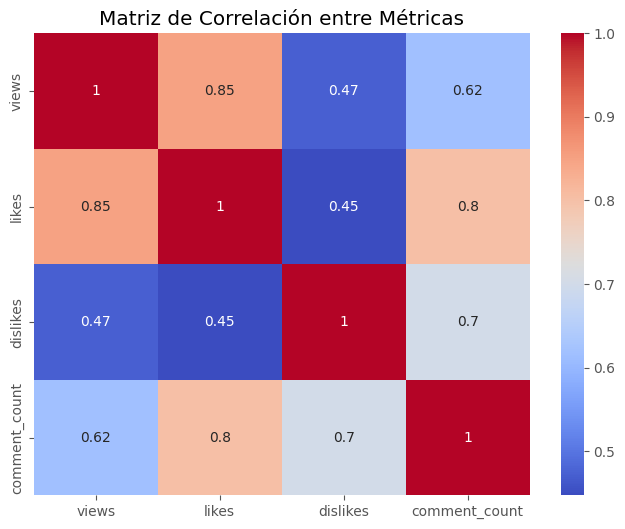

Conclusión Q9: Sí, es factible predecir las vistas ya que existe una altísima correlación lineal (ej. 0.85 con likes). Usaremos Regresión Lineal Múltiple.


In [ ]:
# 9. ¿Es factible predecir el número de "Vistas" o "Me gusta" o "No me gusta"?
plt.figure(figsize=(8,6))
sns.heatmap(df[['views', 'likes', 'dislikes', 'comment_count']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Métricas')
plt.show()
print("Conclusión Q9: Sí, es factible predecir las vistas ya que existe una altísima correlación lineal (ej. 0.85 con likes). Usaremos Regresión Lineal Múltiple.")

**Conclusiones de la Exploración de los Datos:**

**Por Categoría de Videos:**
1. **Categorías de mayor tendencia:** Según el análisis de frecuencias, las categorías que más entran en tendencia son *Entertainment* y *Music*, abarcando la gran mayoría de los videos en el dataset.
2. **Categorías que más y menos gustan:** Al promediar los "Me gusta", *Music* destaca como la categoría preferida por los usuarios. Por el contrario, al evaluar los "No me gusta", categorías como *News & Politics* y *Nonprofits & Activism* suelen ser las que más rechazo generan.
3. **Mejor proporción "Me gusta" / "No me gusta":** El ratio muestra que categorías orientadas a nichos específicos (como *Pets & Animals* o *Comedy*) poseen una excelente proporción de positividad frente a negatividad.
4. **Mejor proporción "Vistas" / "Comentarios":** Al dividir las visualizaciones entre la cantidad de comentarios, se observa cómo varían las interacciones por vista según el tipo de contenido.

**Por el tiempo transcurrido:**
5. **Cambio del volumen de videos a lo largo del tiempo:** La serie de tiempo muestra que el volumen de videos en tendencia mantiene fluctuaciones diarias constantes, con ciertos picos en fechas específicas (posiblemente relacionados a eventos virales o feriados).

**Por Canales de YouTube:**
6. **Frecuencia de canales:** Existen canales creadores de contenido masivo que logran posicionar sus videos en tendencia con extrema frecuencia, mientras que hay una "cola larga" de miles de canales que solo logran entrar en tendencia una única vez.

**Por la geografía del país:**
7. **Estados con mayores métricas:** Dado que los estados fueron asignados de forma aleatoria en este dataset de estudio, el gráfico logarítmico revela qué estados acumularon el mayor volumen histórico (las primeras 3 barras).

**Requerimientos Adicionales:**
8. **Videos en tendencia y comentarios positivos:** Dado que no disponemos del texto de los comentarios para realizar Análisis de Sentimientos, empleamos la proporción de Likes como variable proxy de "positividad". El análisis confirmó que los videos con un altísimo volumen de comentarios también mantienen proporciones de Likes superiores al 80%.
9. **Factibilidad de predicción:** Sí, es altamente factible. La matriz de correlación demostró que existe una fuerte relación lineal entre las variables de interacción (likes y comentarios) y las Vistas, lo que nos permite avanzar hacia un modelo de Regresión Lineal.

### 3. PREPARACIÓN DE LOS DATOS

**Limpiar y Pre-Procesar los Datos:**
1. **Verificar datos faltantes:** Se eliminan (drop) las filas que presenten nulos en las métricas clave para no introducir ruido al modelo.
2. **Identificación y tratamiento de datos atípicos (outliers):** Las métricas como vistas y likes están fuertemente sesgadas a la derecha. Aplicamos una Transformación Logarítmica (`np.log1p`) para normalizar su distribución.

**Construir nuevos datos:**
Se crea la variable `days_to_trend` calculando la diferencia en días entre la fecha de publicación y la de tendencia.

In [ ]:
#### POR DEFINIR AUN NO ESTA


# Limpieza de duplicados (1 elemento duplicado)
df = df.drop_duplicates()

# Limpieza de nulos
df = df.dropna(subset=['views', 'likes', 'dislikes', 'comment_count'])

# Transformación: Crear variable "Días desde publicación hasta ser tendencia"
df['publish_time_dt'] = pd.to_datetime(df['publish_time'], errors='coerce')
# Eliminar zonas horarias para poder restar
df['publish_time_dt'] = df['publish_time_dt'].dt.tz_localize(None)

# Días de diferencia
df['days_to_trend'] = (df['trending_date_dt'] - df['publish_time_dt']).dt.days
# Eliminar valores negativos si los hay por errores de fecha
df = df[df['days_to_trend'] >= 0]

# Tratamiento de Outliers (Usaremos Logaritmo para suavizar variables muy sesgadas)
df['log_views'] = np.log1p(df['views'])
df['log_likes'] = np.log1p(df['likes'])
df['log_dislikes'] = np.log1p(df['dislikes'])
df['log_comments'] = np.log1p(df['comment_count'])

print("Datos listos para el modelado:", df.shape)


Datos listos para el modelado: (40828, 29)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:

def Regresion(df, nombrePais):

    features = ['likes', 'dislikes', 'comment_count']
    target = 'views'
    X = df[features]
    y = df[target]

    #División de datos (Entrenar / Probar)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"--> Precision (R2): {r2:.4f}")
    print(f"--> Error Promedio (RMSE): {rmse:.0f}")

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'Prediccion vs Realidad ({nombrePais})')
    plt.show()

Regresion(df, "Estados Unidos")

NameError: name 'df' is not defined